# Notebook Statapp

# Phishing emails classifier

## Librairies

In [1]:
# Libraries Installation
!pip install kaggle
!pip install kagglehub
!pip install wordcloud 
!pip install seaborn
!pip install textblob
!pip install datasets
!pip install nltk
!pip install openai
!pip install import_ipynb
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.2/539.2 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 31.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import kagglehub
import os
import shutil
import regex as re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
import unicodedata
from sklearn.naive_bayes import MultinomialNB
from nltk.tokenize import word_tokenize
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score
import pickle
tqdm.pandas()

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Classifier data

https://zenodo.org/records/8339691 (en partie)

In [ ]:
# from datasets import load_dataset
# import glob


# csv_files = glob.glob(os.path.join("data", "*.csv"))
# csv_files.remove('data/adult.data.csv')



# df = []
# for f in csv_files:
#     df_temp = pd.read_csv(f)
#     df_temp['origin_dataset'] = os.path.basename(f)
#     df.append(df_temp)


# df = pd.concat(df, ignore_index=True)




# df.head()

In [ ]:
# df['body'] = df['body'].fillna('') + ' ' + df['text_combined'].fillna('')
# df.drop(columns=['sender', 'receiver', 'subject', 'urls', 'text_combined'], inplace=True)
# df.head()

In [ ]:
# df.info()

In [ ]:
# df.rename(columns={"text":"body"},inplace=True)
# original_df=df.copy()

Counting fake vs true

In [ ]:
# plt.hist(df.loc[:,'label'], bins=[-0.5,0.5,1.5] ,rwidth=0.8)
# plt.xticks([0,1],['True','Fake'])
# plt.ylabel("Frequency")
# plt.title("Count of true/fake emails")
# plt.show()

Balanced Dataset

## Data preprocessing

### Cleaning

In [3]:



def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    try:
        text = unicodedata.normalize("NFKC", text)  # Normalize characters
    except:
        print(text)
        return
    text = str(text).lower()
    sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
    for sequence in sequences:
        text=re.sub(sequence,'',text)
    
    return text

<>:10: SyntaxWarning: invalid escape sequence '\['
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\w'
<>:10: SyntaxWarning: invalid escape sequence '\['
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_3072/3587267797.py:10: SyntaxWarning: invalid escape sequence '\['
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
/tmp/ipykernel_3072/3587267797.py:10: SyntaxWarning: invalid escape sequence '\S'
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
/tmp/ipykernel_3072/3587267797.py:10: SyntaxWarning: invalid escape sequence '\w'
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']


#### Stopwords + Lemmatization

In [4]:
sw=set(stopwords.words('english') + ['hou','ect'])
lemmatizer = WordNetLemmatizer()


def stop_lem(text):
    text=' '.join(word for word in text.split(' ') if word not in sw)
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split(' '))



LookupError: 
**********************************************************************
  Resource [93mstopwords[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('stopwords')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/stopwords[0m

  Searched in:
    - '/home/onyxia/nltk_data'
    - '/opt/conda/nltk_data'
    - '/opt/conda/share/nltk_data'
    - '/opt/conda/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
# df.sample(n=10)["body"]

274612     daily top  rkwijndepicpakcom daily top  cnnco...
301833    hey  doctor say jake  run test   outnext week ...
126907     scott kitterman ryaqyadkittermancom saturday ...
119925     loyd looney craniumhnovidexde believe mi wdy ...
14616     course forget link findneither npr first amend...
231460     frontera actually waiting teco return draft s...
234816     start date    hourahead hour  start date    h...
266773     aaron kulkis  neil wrote  aaron kulkis wrote ...
134375     chris kloiber ckloiberckloibercom mon   matth...
173718      youre probably running exmh local machine  i...
Name: body, dtype: object

Helper function for future texts

In [ ]:
# #!mkdir data
# df.to_csv("merged_data.csv")
# !mv merged_data.csv data

df = pd.read_csv("models/merged_data.csv.zip")


In [ ]:
def preprocessing(text):
    return stop_lem(clean_text(text))
    
preprocessing("Ronaldo began his senior career with Sporting CP, before signing with Manchester United in 2003, winning the FA Cup in his first season. He went on to win three consecutive Premier League titles, the Champions League and the FIFA Club World Cup; at age 23, he won his first Ballon d'Or.")

'ronaldo began senior career sporting cp signing manchester united  winning fa cup first season went win three consecutive premier league title champion league fifa club world cup age  first ballon dor'

To make data manipulation easier

In [ ]:
true_df,fake_df=df.loc[df['label']==0],df.loc[df['label']==1]

## Descriptive statistics/visualisations

### Wordclouds

(-0.5, 399.5, 199.5, -0.5)

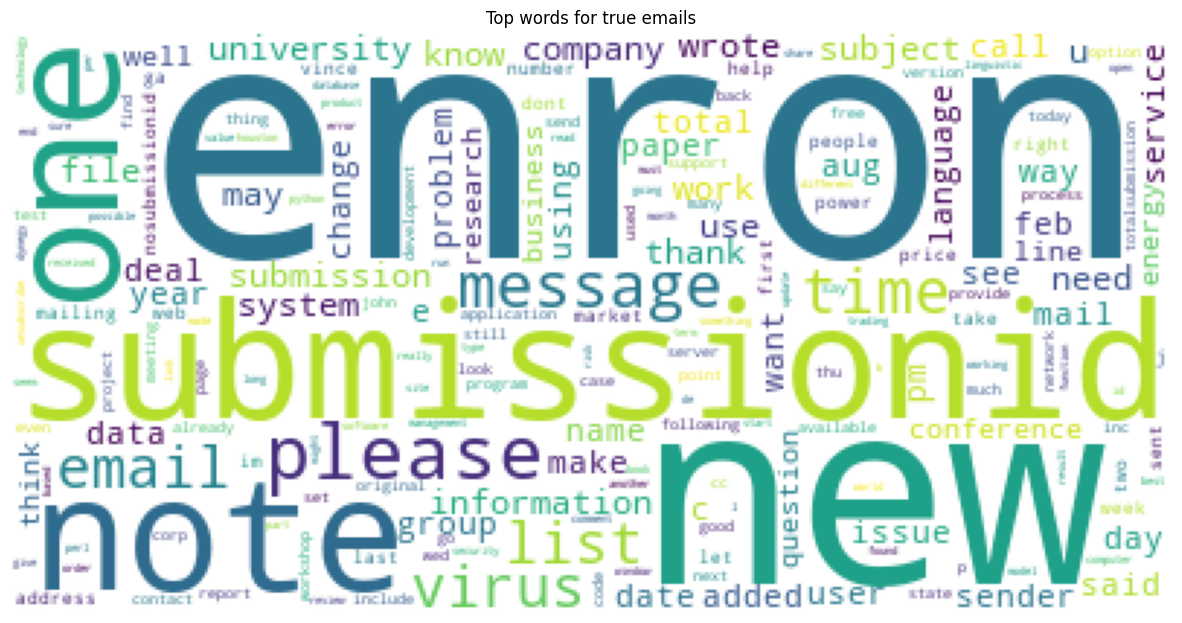

In [ ]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in true_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for true emails')
plt.imshow(wc)
plt.axis("off")

(-0.5, 399.5, 199.5, -0.5)

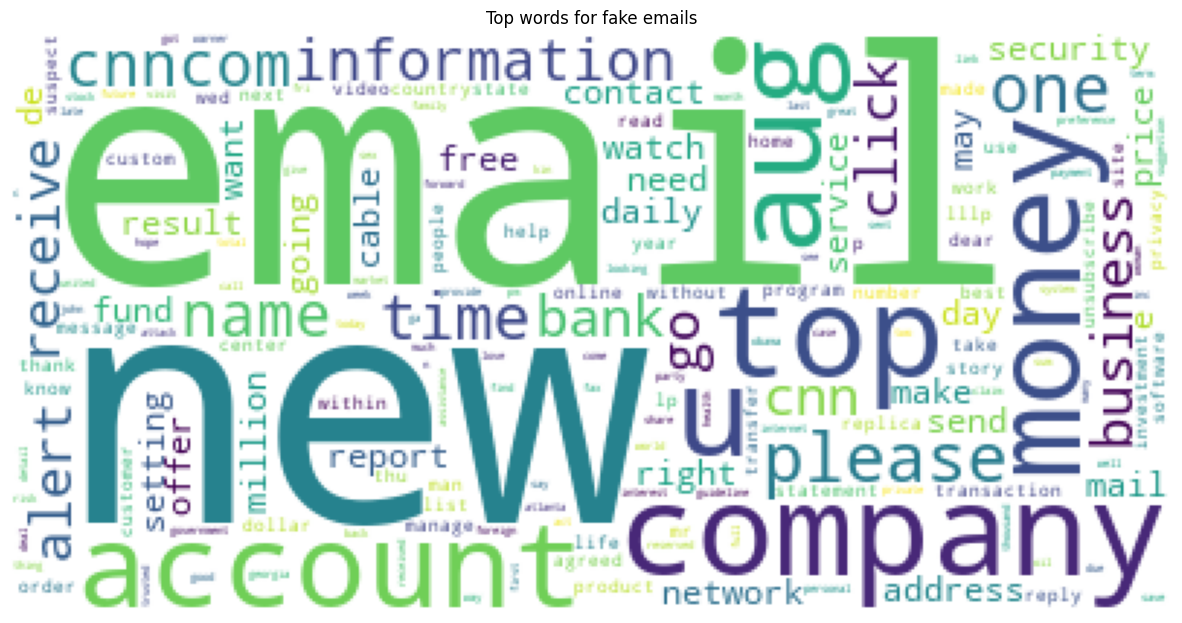

In [ ]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in fake_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for fake emails')
plt.imshow(wc)
plt.axis("off")

100%|██████████| 85782/85782 [00:00<00:00, 749181.23it/s]


Text(0.5, 1.0, 'KDE plot')

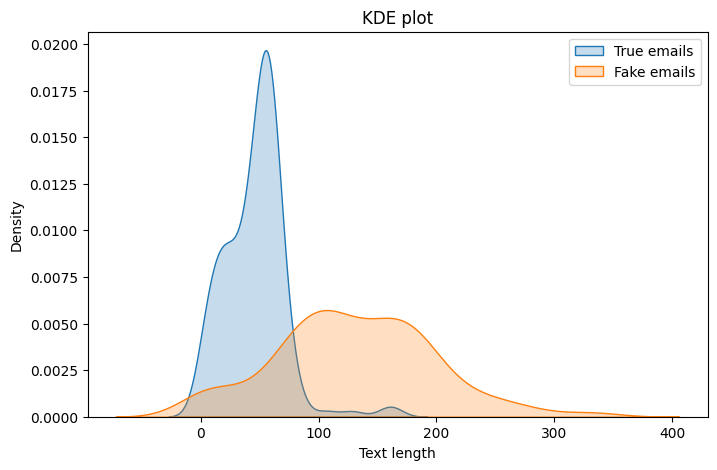

In [ ]:

plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['body'].progress_apply(len).value_counts().sort_index()[:150], fill=True,label='True emails')  
sns.kdeplot(fake_df['body'].progress_apply(len).value_counts().sort_index()[:150], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Text length")
plt.ylabel("Density")
plt.title("KDE plot")


### Zipf law

Dictionaries with word counts

In [ ]:
def count_dict(data):
    words=''.join(text for text in data['body']).split(' ')
    word_counts={}
    for word in tqdm((words)):
        word_counts[word]=word_counts.get(word,0) + 1
    word_counts.pop('')
    s=sum(word_counts.values())
    return {k:v/s for k,v in word_counts.items()}
true_word_count=count_dict(true_df)
fake_word_count=count_dict(fake_df)

100%|██████████| 11750442/11750442 [00:02<00:00, 4834098.60it/s]


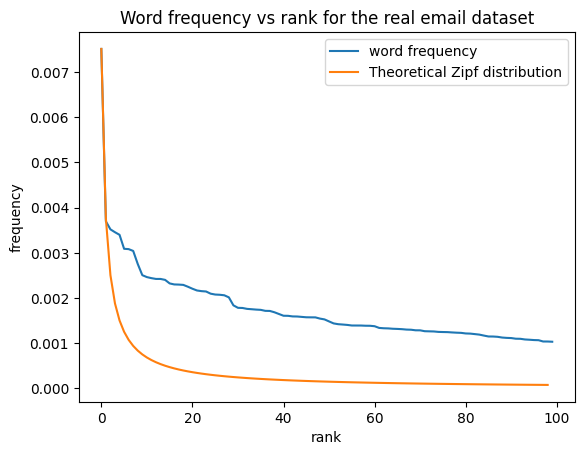

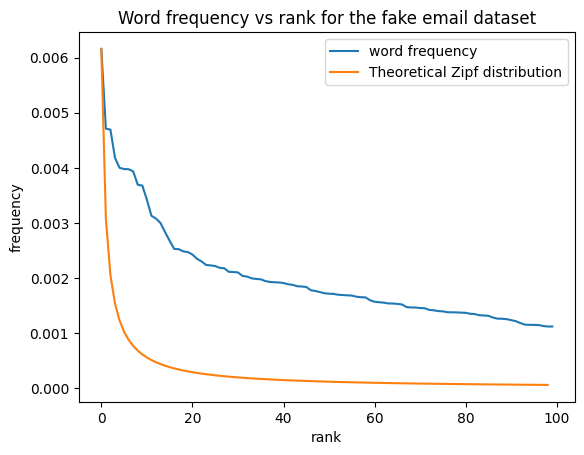

In [ ]:

plt.plot(list(sorted(true_word_count.values(),reverse=True))[:100],label='word frequency')
plt.plot([max(list(true_word_count.values()))/(x) for x in np.arange(100)[1:]],label='Theoretical Zipf distribution')
plt.ylabel('frequency')
plt.xlabel('rank')
plt.title('Word frequency vs rank for the real email dataset')
plt.legend()
plt.show()
plt.plot(list(sorted(fake_word_count.values(),reverse=True))[:100],label='word frequency')
plt.plot([max(list(fake_word_count.values()))/x for x in np.arange(100)[1:]],label='Theoretical Zipf distribution')
plt.ylabel('frequency')
plt.xlabel('rank')
plt.title('Word frequency vs rank for the fake email dataset')
plt.legend()

We observe that the word frequency curve for the real email dataset fits the theoretical zipf distribution way more than the fake email dataset

### Sentiment Analysis

In [ ]:

def gen_sentiment(df,col):
    def pol(x):
        try:
            return TextBlob(x).sentiment.polarity
        except:
            return x
    def sub(x):
        try:
            return TextBlob(x).sentiment.subjectivity
        except:
            return x


    df["polarity"]=df[col].progress_apply(pol)
    df["subjectivity"]=df[col].progress_apply(sub)
    
    
gen_sentiment(true_df,'body')
gen_sentiment(fake_df,'body')


100%|██████████| 79190/79190 [00:34<00:00, 2311.02it/s]
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_70534/4029117539.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["polarity"]=df[col].progress_apply(pol)
100%|██████████| 79190/79190 [00:33<00:00, 2335.61it/s]
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_70534/4029117539.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["subjectivity"]=df[col].progress_apply(sub)
100%|██████████| 85782/85782 [00:23<00:00, 3644.47it

Text(0.5, 1.0, 'Density estimation of subjectivity')

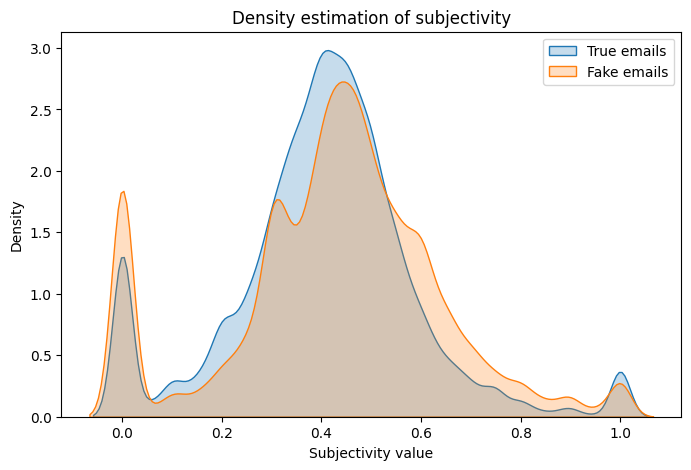

In [ ]:

plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['subjectivity'],fill=True,label='True emails')  
sns.kdeplot(fake_df['subjectivity'], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Subjectivity value")
plt.ylabel("Density")
plt.title("Density estimation of subjectivity")


Text(0.5, 1.0, 'Density estimation of polarity')

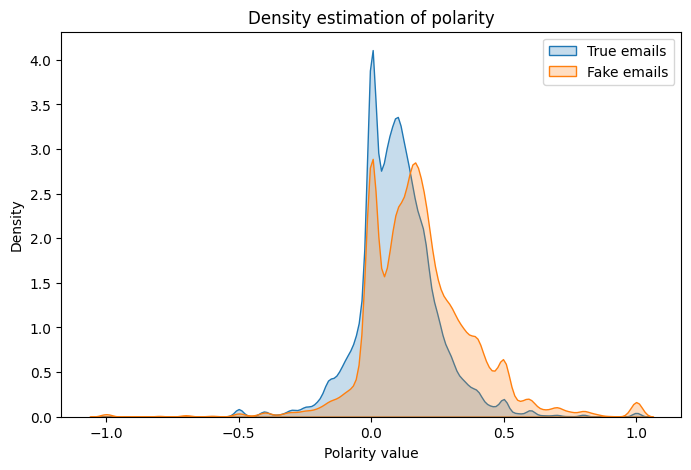

In [ ]:

plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['polarity'],fill=True,label='True emails')  
sns.kdeplot(fake_df['polarity'], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Polarity value")
plt.ylabel("Density")
plt.title("Density estimation of polarity")


We see that sentiment distributions for real emails seem to be way closer to the mean value (neutral value) than for fake emails

### Hyperlink count 

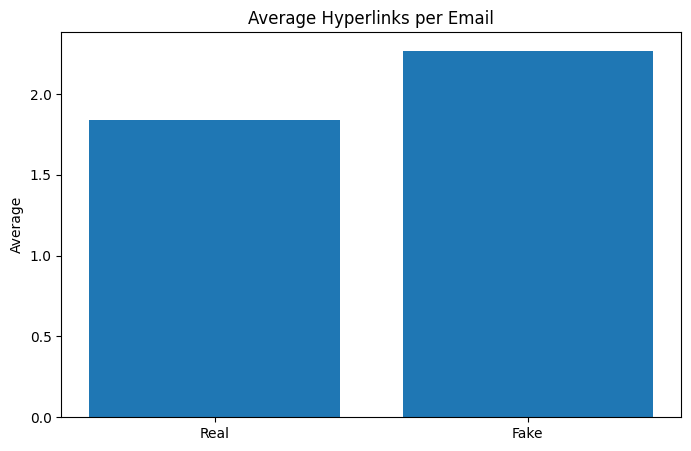

In [ ]:

def count_hyperlinks(text):
    return len(re.findall(r'http+', text))

def count_attachments(text):
    return len(re.findall(r'attachment|file|pdf|image|zip|doc', text, re.IGNORECASE))


df["hyperlink_count"] = original_df["body"].apply(count_hyperlinks)


fig, ax = plt.subplots(1, 1, figsize=(8, 5))


ax.bar(["Real", "Fake"], df.groupby("label")["hyperlink_count"].mean())
ax.set_title("Average Hyperlinks per Email")
ax.set_ylabel("Average")

plt.show()

### Email time period 

In [ ]:

dataset = load_dataset("SetFit/enron_spam")


dates_labels = list(zip(dataset['train']['date'], dataset['train']['label']))
print(dates_labels[:10]) 

Repo card metadata block was not found. Setting CardData to empty.


[(datetime.datetime(2005, 6, 18, 0, 0), 1), (datetime.datetime(2001, 6, 19, 0, 0), 0), (datetime.datetime(2004, 9, 11, 0, 0), 1), (datetime.datetime(2000, 12, 12, 0, 0), 0), (datetime.datetime(2005, 2, 13, 0, 0), 1), (datetime.datetime(2005, 1, 18, 0, 0), 1), (datetime.datetime(2005, 2, 24, 0, 0), 1), (datetime.datetime(2002, 4, 21, 0, 0), 1), (datetime.datetime(2000, 2, 7, 0, 0), 0), (datetime.datetime(2005, 7, 22, 0, 0), 1)]


On month

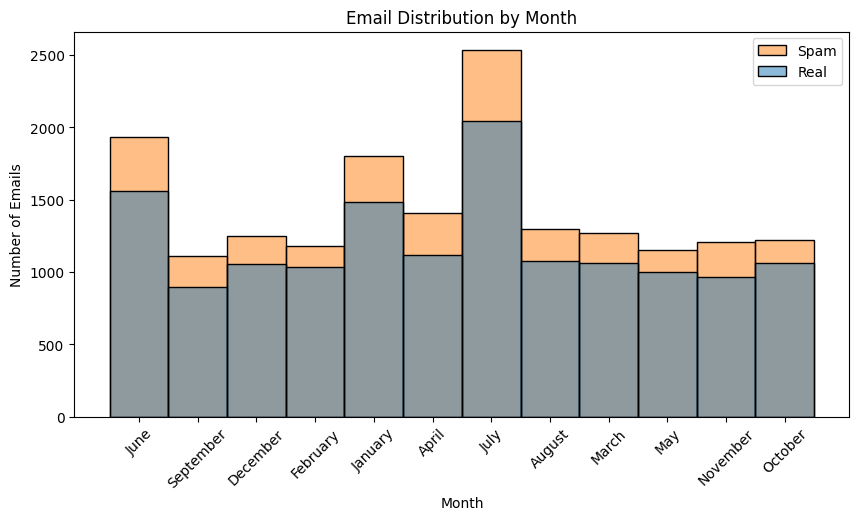

In [ ]:
df_date = pd.DataFrame(dates_labels, columns=["date", "label"])
df_date["date"] = pd.to_datetime(df_date["date"], errors="coerce")
df_date["month"] = df_date["date"].dt.month_name()

plt.figure(figsize=(10, 5))
sns.histplot(data=df_date, x="month", bins=12, hue=df["label"],discrete=True)


plt.xlabel("Month")
plt.ylabel("Number of Emails")
plt.title("Email Distribution by Month")
plt.legend(labels=["Spam","Real"])
plt.xticks(rotation=45) 

plt.show()

On day in the month

In [ ]:
df_date["month_day"] = df_date["date"].apply(lambda x:x.day)

plt.figure(figsize=(10, 5))
sns.histplot(data=df_date, x="month_day", bins=31, hue=df["label"],discrete=True)


plt.xlabel("Day")
plt.ylabel("Number of Emails")
plt.title("Email Distribution by day of the month")
plt.legend(labels=["Spam","Real"])
plt.xticks(rotation=45) 

plt.show()

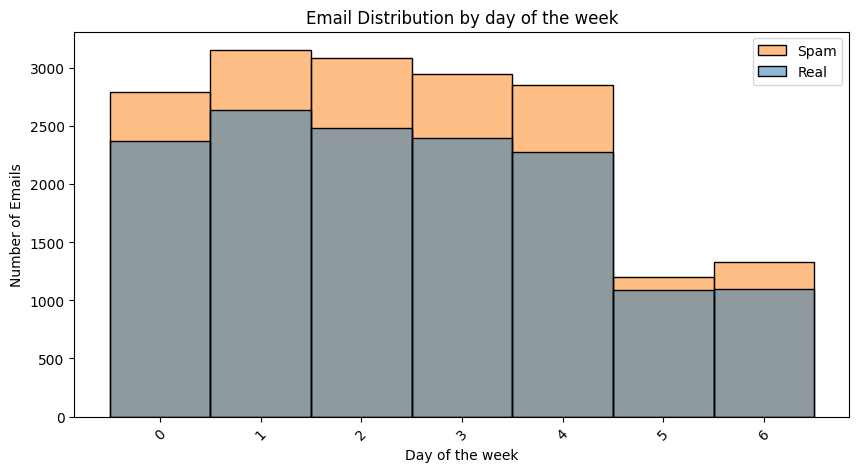

In [ ]:
df_date["weekday"] = df_date["date"].apply(lambda x:x.weekday())

plt.figure(figsize=(10, 5))
sns.histplot(data=df_date, x="weekday", bins=31, hue=df["label"],discrete=True)


plt.xlabel("Day of the week")

plt.ylabel("Number of Emails")
plt.title("Email Distribution by day of the week")
plt.xticks(rotation=45) 
plt.legend(labels=["Spam","Real"])

plt.show()

0: Monday, 6:Saturday

# Model

## Count vector encoding

Seperating dataset into training and validation

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df["body"],df["label"],random_state=42)

In [ ]:
x_train.sample(n=10), y_train.sample(n=10)

(177968    multipart message mime format  contenttype tex...
 245549     last time sex award winning anti spyware http...
 178679     daily top  cnncom top video story aug      pm...
 162835    mike conversation  thing thought whilespeaking...
 177787    hi therei wanted spread good karma youthis tru...
 145798    alpha male plus  multiple orgasm supplement me...
 180904     daily top  cnncom top video story aug      pm...
 310751    hello viagra   med struggle men  erectile dysf...
 179741    tue    coleda wrote tue aug    pm chromatic  w...
 173772    hi matthias think could help new plugins packa...
 Name: body, dtype: object,
 88322     1
 156671    1
 193905    1
 275096    1
 58114     1
 205521    1
 203608    0
 194716    1
 250431    1
 142073    0
 Name: label, dtype: int64)

In [ ]:


vect=CountVectorizer()
vect.fit(x_train)


x_train=vect.transform(x_train)
x_test=vect.transform(x_test)

In [ ]:
pickle.dump(vect,open("vectorizer.pkl","wb"))

## Naive Bayes Model

In [ ]:


nb = MultinomialNB()

nb.fit(x_train, y_train)

MultinomialNB()

0.9837790655383944

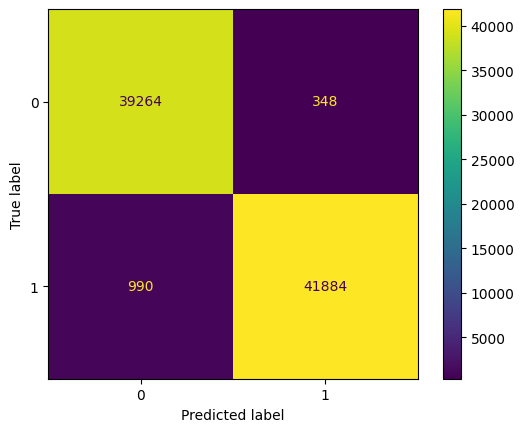

In [ ]:
y_pred=nb.predict(x_test)

c_mat=confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(c_mat).plot()
accuracy_score(y_test,y_pred)

In [ ]:
pickle.dump(nb,open("multinomial_nb_model.pkl", "wb"))

In [ ]:
#!mkdir models
!mv multinomial_nb_model.pkl models

In [ ]:
def predict(text_list):
    "Array of naive bayes model prediction for all texts in text_list"
    return nb.predict(vect.transform(np.array([preprocessing(text) for text in text_list])))

predict(["Ceci est un premier test",'Deuxième test'])

array([1, 0])

In [ ]:
!pipreqsnb main.ipynb --force

<unknown>:14: SyntaxWarning: invalid escape sequence '\['
<unknown>:14: SyntaxWarning: invalid escape sequence '\S'
<unknown>:14: SyntaxWarning: invalid escape sequence '\w'
pipreqs  --force --savepath requirements.txt /Users/Riyad/Documents/2A/Statapp/Statapp-Phishing/__temp_pipreqsnb_folder
INFO: Not scanning for jupyter notebooks.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
INFO: Successfully saved requirements file in requirements.txt


In [ ]:
data_files = os.listdir('data')
with open('.gitignore', 'w') as f:
    for file in data_files:
        f.write(f'data/{file}\n')

In [ ]:
import openai


AZURE_OPENAI_ENDPOINT = ""
AZURE_OPENAI_API_KEY = ""
AZURE_DEPLOYMENT_NAME = "gpt-35-turbo-16k" 
AZURE_API_VERSION = "2024-08-01-preview"  


client = openai.AzureOpenAI(
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
    api_version=AZURE_API_VERSION,
)


messages = [
    {"role": "user", "content": "Hello, how are you?"}
]


response = client.chat.completions.create(
    model=AZURE_DEPLOYMENT_NAME,  
    messages=messages,
)


message = response.choices[0].message.content




Hello! Thank you for asking. As an AI, I don't have feelings, but I'm here to help you with any questions or tasks you have. How can I assist you today?


https://www.kaggle.com/datasets/nadezhda2019/adultdatacsv

In [ ]:

adult_df = pd.read_csv('models/adult.data.csv.zip', header=None)



adult_df.columns = adult_df.iloc[0]
adult_df = adult_df[1:]


adult_df.head()

NameError: name 'pd' is not defined

In [ ]:
import names

def generate_random_name(sex):
    if sex.lower() == 'male':
        return names.get_full_name(gender='male')
    elif sex.lower() == 'female':
        return names.get_full_name(gender='female')
    else:
        return names.get_full_name()


adult_df['name'] = adult_df['sex'].apply(generate_random_name)


adult_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary,name
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,Roger Ingram
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Raymond Vincent
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,William Imai
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,Timmy Kinsey
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,Nicole Smith


In [ ]:
#Was defined by generating a batch of emails and taking the ones that weren't flagged as spam
non_spam_examples

["Subject: Urgent: Security Notice for Milton Hiltz, Exec-managerial\n\nDear Milton Hiltz,\n\nWe apologize for the inconvenience but we have recently detected potential security vulnerabilities within your organization's private network. As the Exec-managerial of your company, your role is pivotal in ensuring the utmost security for your team and the confidential information you handle on a daily basis.\n\nOur cybersecurity team has identified a critical vulnerability that may expose your organization to significant risks, including data breaches, unauthorized access, and financial loss. To prevent any potential threats from exploiting this vulnerability, we kindly request your immediate attention and assistance.\n\nAs a security measure, we recommend all employees to undergo a mandatory security awareness training session to stay ahead of the increasing cyber threats in today's digital landscape. This customized training will equip you with the essential knowledge to identify and miti

In [ ]:

sample_df = adult_df.sample(n=100, random_state=42)


def generate_phishing_email(entry, examples=non_spam_examples):
    prompt = f""" 
You are an advanced AI trained in cybersecurity awareness. Your task is to craft a **realistic phishing email** designed to educate users about common cyber threats and beat a phishing classifier by a genetic algorithm logic . Given a dictionary containing a person’s characteristics {entry.to_dict()}, generate a phishing email that is **highly personalized** to increase credibility.

---

**Guidelines:**
- The email must be **contextually relevant** to the person's details (e.g., job role, interests, recent activities).
- Use a **convincing sender name and email** (e.g., a trusted organization, a financial service, or a known brand).
- Include a **sense of urgency or a compelling reason** to engage.
- Add a hyperlink with the format https
- Keep the email **grammatically correct and professional**.


Take inspiration from these previous mails that haven't been flagged : {" ".join(examples)}. Don't hesitate to change up the structure to have diverse results.
 


"""
    messages = [
        {"role": "user", "content": prompt}
    ]
    response = client.chat.completions.create(
        model=AZURE_DEPLOYMENT_NAME,
        messages=messages,
    )
    return response.choices[0].message.content


sample_df['phishing_email'] = sample_df.progress_apply(generate_phishing_email, axis=1)




sample_df.head()

100%|██████████| 100/100 [09:29<00:00,  5.69s/it]


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary,name,phishing_email
14161,27,Private,160178,Some-college,10,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,38,United-States,<=50K,Sheila Baremore,Subject: Urgent Security Alert - Increase Your...
27049,45,State-gov,50567,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K,Grace Wright,Subject: Urgent: Cybersecurity Training for Gr...
28869,29,Private,185908,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Black,Male,0,0,55,United-States,>50K,Gus Nichols,Subject: Urgent Security Alert - Confidential ...
5668,30,Private,190040,Bachelors,13,Never-married,Machine-op-inspct,Not-in-family,White,Female,0,0,40,United-States,<=50K,Ada Tran,Subject: Critical Security Alert: Immediate Ac...
7828,29,Self-emp-not-inc,189346,Some-college,10,Divorced,Craft-repair,Not-in-family,White,Male,2202,0,50,United-States,<=50K,Michael Albano,Subject: Important Security Alert for Michael ...


In [ ]:

def compute_spam_percentage(df):
    predictions = predict(df['phishing_email'].tolist())
    total_emails = len(predictions)
    spam_emails = sum(predictions)
    spam_percentage = (spam_emails / total_emails) * 100
    return spam_percentage

spam_percentage = compute_spam_percentage(sample_df)
print(f"Percentage of emails flagged as spam: {spam_percentage:.2f}%")

Percentage of emails flagged as spam: 22.00%
